# 🎙️ Speech Emotion Recognition (SER)
### Deep Learning Class Project

**Team Project** | Datasets: RAVDESS · TESS · SAVEE

---

## 📌 1. Problem Statement

### 1.1 Overview

Speech Emotion Recognition (SER) is the task of automatically identifying a speaker's emotional state from their voice. Unlike text-based sentiment analysis, SER operates directly on raw audio signals, capturing paralinguistic cues (pitch, energy, tempo, timbre) that reflect emotional content independent of the words spoken.

### 1.2 Objective

> **Given a short audio clip of speech, classify the speaker's emotion into one of N discrete categories (e.g., neutral, calm, happy, sad, angry, fearful, disgusted, surprised).**

This is a **multi-class classification** problem. The input is a raw audio waveform (or derived spectral features), and the output is a predicted emotion label.

### 1.3 Real-World Applications

| Domain | Application |
|---|---|
| 🧠 Mental Health | Automated depression/anxiety screening from voice journals or therapy sessions |
| 📞 Call Centers | Real-time customer frustration detection to escalate calls or adjust agent tone |
| 🚗 Automotive | In-vehicle driver monitoring to detect stress or fatigue and trigger alerts |
| 🎮 Gaming / VR | Dynamic NPC behavior and adaptive game difficulty based on player emotional state |
| 🤖 Social Robots | Empathetic human-robot interaction (e.g., companions for elderly or special needs) |
| 📚 Education | Intelligent tutoring systems that adapt to student frustration or confusion in real time |
| 🏥 Telemedicine | Longitudinal emotional tracking for patients with Parkinson's, dementia, or PTSD |

### 1.4 Why Deep Learning?

Traditional SER pipelines rely on hand-crafted features (MFCCs, ZCR, chroma) fed into shallow classifiers (SVM, GMM). Deep learning approaches—CNNs on spectrograms, RNNs/LSTMs on temporal sequences, and Transformer-based models—can learn hierarchical representations directly from data, reducing the need for domain-specific feature engineering and achieving state-of-the-art performance on benchmark datasets.

### 1.5 Success Metric

- **Primary:** Weighted F1-score (accounts for class imbalance)
- **Secondary:** Overall accuracy, per-class recall (confusion matrix analysis)
- **Baseline target:** Outperform majority-class baseline; aim for ≥70% weighted F1 on held-out test set

---

## ⚙️ 2. Setup & Dataset Loading

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install kagglehub librosa soundfile seaborn matplotlib pandas numpy scikit-learn tqdm

import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from tqdm.notebook import tqdm
from IPython.display import Audio, display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("All imports successful ✅")

All imports successful ✅


In [2]:
# ── Download datasets via KaggleHub ──────────────────────────────────────────
import kagglehub

ravdess_path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
tess_path    = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")
savee_path   = kagglehub.dataset_download("ejlok1/surrey-audiovisual-expressed-emotion-savee")

print(f"RAVDESS → {ravdess_path}")
print(f"TESS    → {tess_path}")
print(f"SAVEE   → {savee_path}")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.
Using Colab cache for faster access to the 'surrey-audiovisual-expressed-emotion-savee' dataset.
RAVDESS → /kaggle/input/ravdess-emotional-speech-audio
TESS    → /kaggle/input/toronto-emotional-speech-set-tess
SAVEE   → /kaggle/input/surrey-audiovisual-expressed-emotion-savee


## 📂 3. Parse File Paths & Build Unified DataFrame

Each dataset encodes emotion differently in the filename/folder structure. We normalise everything into a single DataFrame with columns: `[filepath, dataset, emotion, actor, gender]`.

In [3]:
# ── RAVDESS label map ─────────────────────────────────────────────────────────
# Filename: 03-01-06-01-02-01-12.wav
# Position 3 (1-indexed) = emotion code
RAVDESS_EMOTIONS = {
    '01': 'neutral',  '02': 'calm',     '03': 'happy',
    '04': 'sad',      '05': 'angry',    '06': 'fearful',
    '07': 'disgust',  '08': 'surprised'
}

def parse_ravdess(root):
    records = []
    for fp in glob.glob(os.path.join(root, '**', '*.wav'), recursive=True):
        parts = Path(fp).stem.split('-')
        if len(parts) < 7:
            continue
        emo_code = parts[2]
        actor_id = int(parts[6])
        gender   = 'female' if actor_id % 2 == 0 else 'male'
        records.append({
            'filepath': fp,
            'dataset':  'RAVDESS',
            'emotion':  RAVDESS_EMOTIONS.get(emo_code, 'unknown'),
            'actor':    f'RAVDESS_{actor_id:02d}',
            'gender':   gender
        })
    return records

# ── TESS label map ────────────────────────────────────────────────────────────
# Folder name: OAF_angry, YAF_happy, etc.
# Speaker prefix: OAF = older female, YAF = younger female
TESS_EMOTIONS = {
    'angry': 'angry', 'disgust': 'disgust', 'fear': 'fearful',
    'happy': 'happy', 'neutral': 'neutral', 'sad': 'sad', 'ps': 'surprised'
}

def parse_tess(root):
    records = []
    for fp in glob.glob(os.path.join(root, '**', '*.wav'), recursive=True):
        folder = Path(fp).parent.name.lower()   # e.g. 'OAF_angry'
        parts  = folder.split('_')
        if len(parts) < 2:
            continue
        speaker_prefix = parts[0].upper()        # OAF or YAF
        emo_raw        = '_'.join(parts[1:])
        emotion        = TESS_EMOTIONS.get(emo_raw, emo_raw)
        records.append({
            'filepath': fp,
            'dataset':  'TESS',
            'emotion':  emotion,
            'actor':    f'TESS_{speaker_prefix}',
            'gender':   'female'   # TESS is all-female
        })
    return records

# ── SAVEE label map ───────────────────────────────────────────────────────────
# Filename prefix: a=angry, d=disgust, f=fear, h=happy, n=neutral, sa=sad, su=surprise
SAVEE_EMOTIONS = {
    'a':  'angry',    'd':  'disgust', 'f':  'fearful',
    'h':  'happy',    'n':  'neutral', 'sa': 'sad',
    'su': 'surprised'
}

def parse_savee(root):
    records = []
    for fp in glob.glob(os.path.join(root, '**', '*.wav'), recursive=True):
        stem    = Path(fp).stem                 # e.g. 'DC_a01'
        parts   = stem.split('_')
        if len(parts) < 2:
            continue
        actor_id = parts[0]
        emo_part = re.sub(r'[0-9]', '', parts[1])  # strip trailing digits
        emotion  = SAVEE_EMOTIONS.get(emo_part, 'unknown')
        records.append({
            'filepath': fp,
            'dataset':  'SAVEE',
            'emotion':  emotion,
            'actor':    f'SAVEE_{actor_id}',
            'gender':   'male'    # SAVEE is all-male
        })
    return records

# ── Combine ───────────────────────────────────────────────────────────────────
all_records = parse_ravdess(ravdess_path) + parse_tess(tess_path) + parse_savee(savee_path)
df = pd.DataFrame(all_records)
df = df[df['emotion'] != 'unknown'].reset_index(drop=True)

print(f"Total samples: {len(df):,}")
df.head(10)

Total samples: 8,960


,filepath,dataset,emotion,actor,gender
0,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,surprised,RAVDESS_02,female
1,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,neutral,RAVDESS_02,female
2,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,disgust,RAVDESS_02,female
3,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,disgust,RAVDESS_02,female
4,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,neutral,RAVDESS_02,female
5,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,fearful,RAVDESS_02,female
6,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,sad,RAVDESS_02,female
7,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,neutral,RAVDESS_02,female
8,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,calm,RAVDESS_02,female
9,/kaggle/input/ravdess-emotional-speech-audio/A...,RAVDESS,happy,RAVDESS_02,female


## 📊 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset-Level Overview

In [4]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(df.groupby('dataset').agg(
    samples=('filepath', 'count'),
    unique_actors=('actor', 'nunique'),
    unique_emotions=('emotion', 'nunique')
).to_string())
print()
print("EMOTION DISTRIBUTION (all datasets)")
print(df['emotion'].value_counts().to_string())
print()
print("GENDER DISTRIBUTION")
print(df['gender'].value_counts().to_string())

DATASET SUMMARY
         samples  unique_actors  unique_emotions
dataset                                         
RAVDESS     2880             24                8
SAVEE        480              4                7
TESS        5600              2                8

EMOTION DISTRIBUTION (all datasets)
emotion
fearful               1244
disgust               1244
angry                 1244
happy                 1244
sad                   1244
neutral               1112
surprised              444
pleasant_surprise      400
pleasant_surprised     400
calm                   384

GENDER DISTRIBUTION
gender
female    7040
male      1920


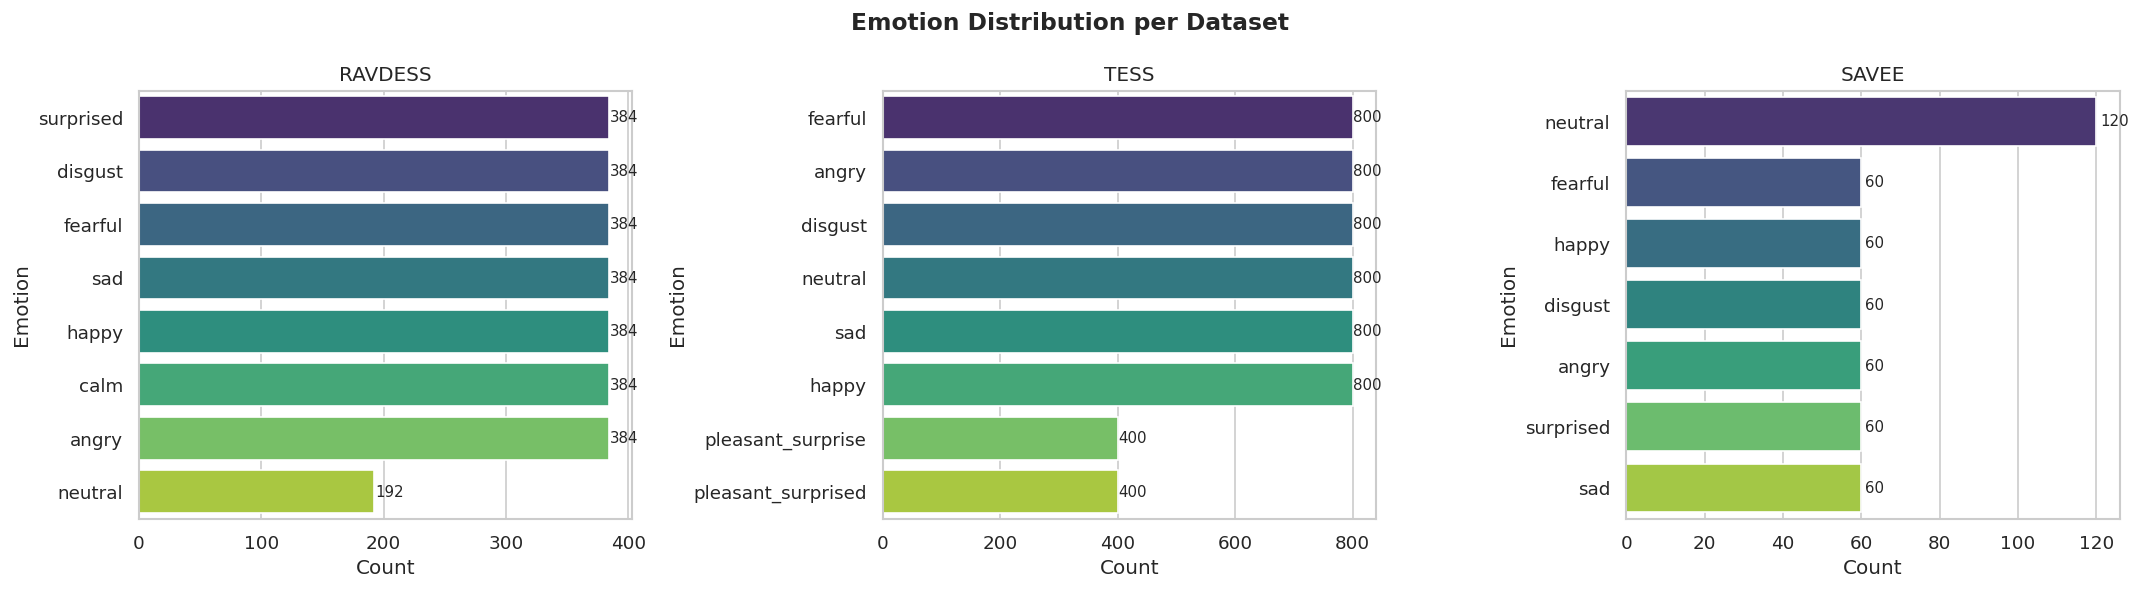

In [5]:
# ── Figure 1: Class distribution across datasets ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Emotion Distribution per Dataset', fontsize=14, fontweight='bold')

for ax, dataset in zip(axes, ['RAVDESS', 'TESS', 'SAVEE']):
    sub = df[df['dataset'] == dataset]
    counts = sub['emotion'].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
    ax.set_title(dataset)
    ax.set_xlabel('Count')
    ax.set_ylabel('Emotion')
    for i, v in enumerate(counts.values):
        ax.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_emotion_distribution.png', bbox_inches='tight')
plt.show()

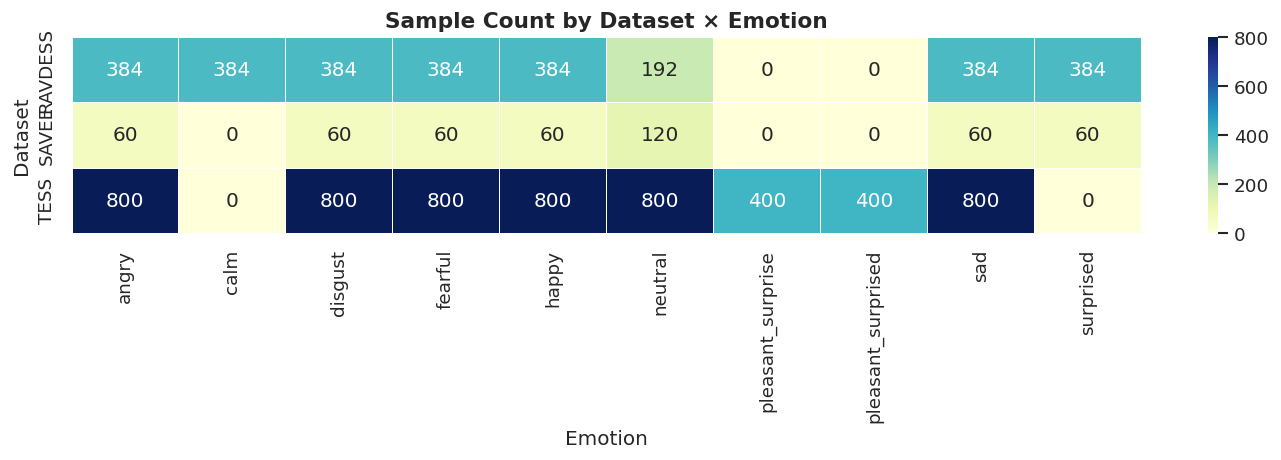


⚠️  Emotions present in ALL three datasets (intersection):
['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']


In [6]:
# ── Figure 2: Emotion overlap heatmap across datasets ─────────────────────────
pivot = df.groupby(['dataset', 'emotion']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title('Sample Count by Dataset × Emotion', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Dataset')
plt.tight_layout()
plt.savefig('eda_emotion_heatmap.png', bbox_inches='tight')
plt.show()

print("\n⚠️  Emotions present in ALL three datasets (intersection):")
per_dataset = df.groupby('dataset')['emotion'].apply(set)
common_emotions = set.intersection(*per_dataset.values)
print(sorted(common_emotions))

### 4.2 Gender & Speaker Balance

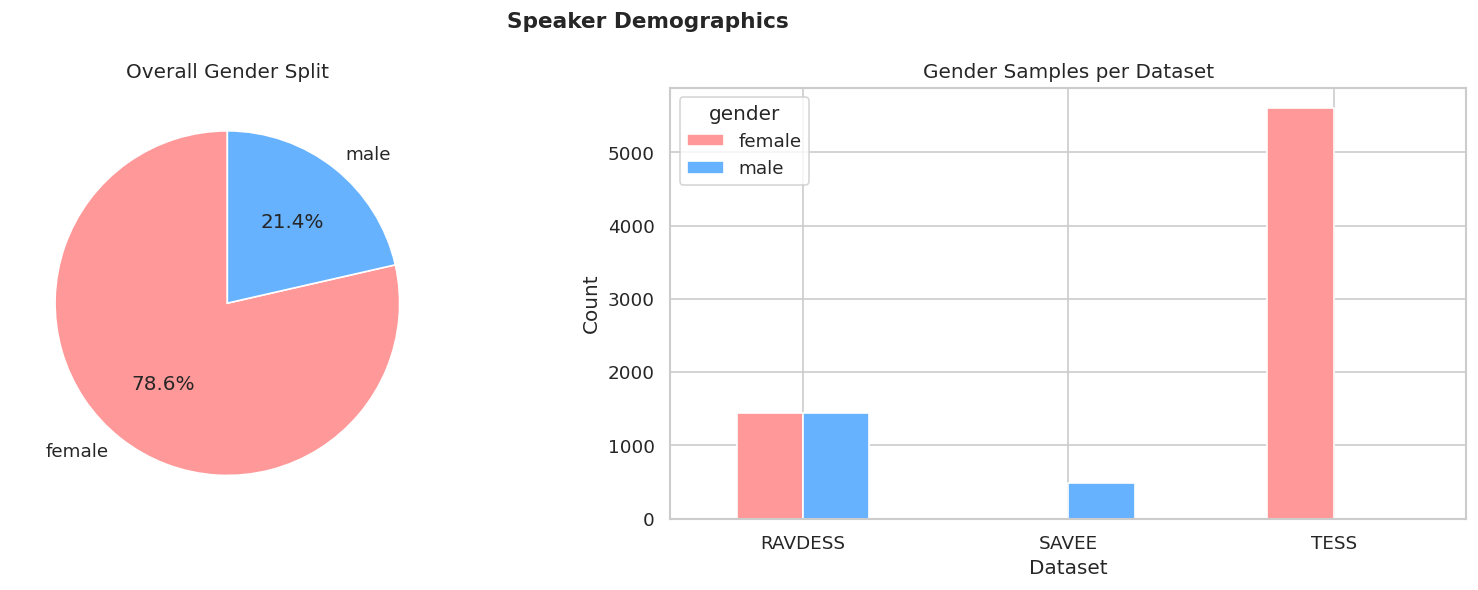


⚠️  NOTE: TESS is all-female; SAVEE is all-male.
This gender imbalance is a known limitation — see Section 6.


In [7]:
# ── Figure 3: Gender & speaker breakdown ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Speaker Demographics', fontsize=13, fontweight='bold')

# Gender pie
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#FF9999', '#66B2FF'], startangle=90)
axes[0].set_title('Overall Gender Split')

# Gender per dataset
g = df.groupby(['dataset', 'gender']).size().unstack(fill_value=0)
g.plot(kind='bar', ax=axes[1], color=['#FF9999', '#66B2FF'], edgecolor='white')
axes[1].set_title('Gender Samples per Dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_gender.png', bbox_inches='tight')
plt.show()

print("\n⚠️  NOTE: TESS is all-female; SAVEE is all-male.")
print("This gender imbalance is a known limitation — see Section 6.")

### 4.3 Audio Duration Analysis

In [8]:
# ── Compute duration for a stratified sample (full scan is slow) ──────────────
SAMPLE_N = 300   # increase for more accuracy, decrease to run faster

sample_df = df.groupby(['dataset', 'emotion'], group_keys=False).apply(
    lambda x: x.sample(min(len(x), max(1, SAMPLE_N // (df['dataset'].nunique() * df['emotion'].nunique()))))
).reset_index(drop=True)

durations = []
sample_rates = []
for fp in tqdm(sample_df['filepath'], desc="Loading audio metadata"):
    try:
        info = sf.info(fp)
        durations.append(info.duration)
        sample_rates.append(info.samplerate)
    except Exception:
        durations.append(np.nan)
        sample_rates.append(np.nan)

sample_df['duration_s'] = durations
sample_df['sample_rate'] = sample_rates
sample_df = sample_df.dropna(subset=['duration_s'])

print(sample_df['duration_s'].describe().round(3))
print("\nUnique sample rates:", sample_df['sample_rate'].value_counts().to_dict())

Loading audio metadata:   0%|          | 0/230 [00:00<?, ?it/s]

count    230.000
mean       3.131
std        1.059
min        1.445
25%        2.164
50%        3.303
75%        3.807
max        6.289
Name: duration_s, dtype: float64

Unique sample rates: {48000: 80, 24414: 80, 44100: 70}


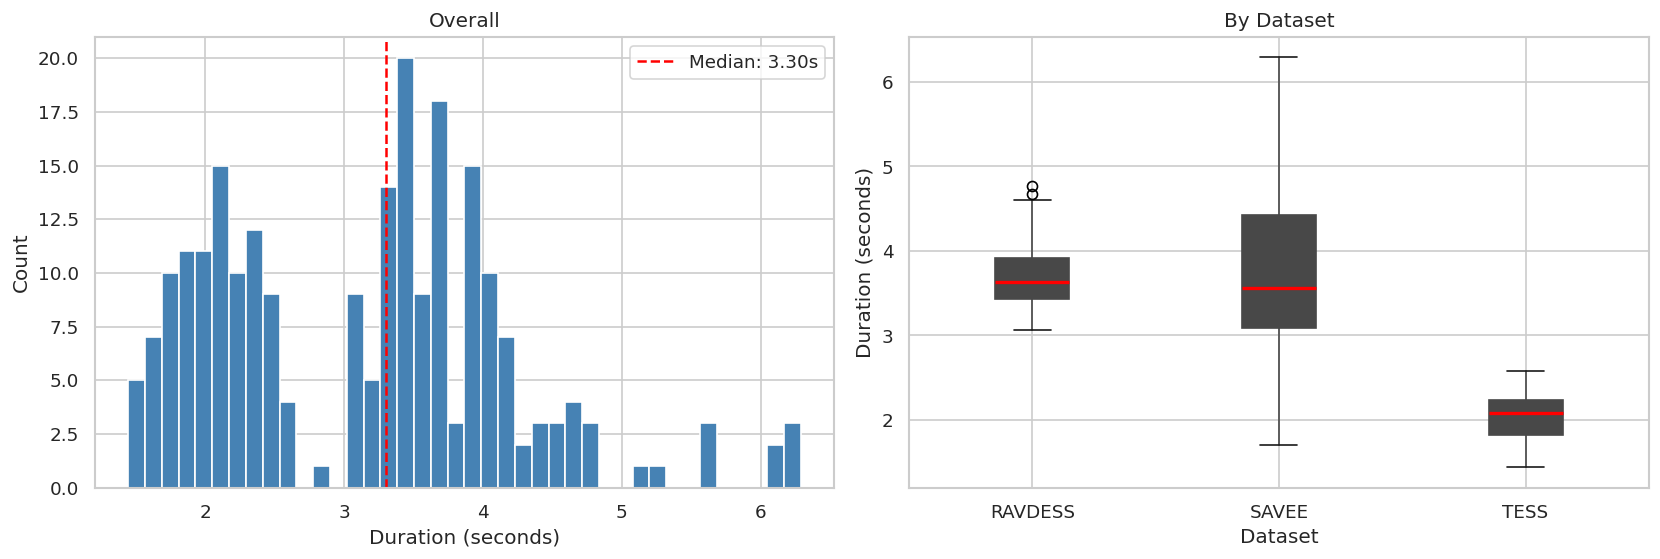

In [9]:
# ── Figure 4: Duration distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Audio Duration Distribution', fontsize=13, fontweight='bold')

# Overall histogram
axes[0].hist(sample_df['duration_s'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(sample_df['duration_s'].median(), color='red', linestyle='--',
                label=f"Median: {sample_df['duration_s'].median():.2f}s")
axes[0].set_title('Overall')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Per dataset boxplot
sample_df.boxplot(column='duration_s', by='dataset', ax=axes[1],
                  patch_artist=True, medianprops=dict(color='red', linewidth=2))
axes[1].set_title('By Dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Duration (seconds)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_duration.png', bbox_inches='tight')
plt.show()

### 4.4 Waveform & Spectrogram Visualisation

We visualise one sample per emotion to build intuition about how different emotions look in the time and frequency domains.

In [10]:
# ── Helper: load one audio clip per emotion (from RAVDESS) ────────────────────
TARGET_SR = 22050
EMOTIONS_TO_PLOT = sorted(df['emotion'].unique())

emotion_examples = {}
for emo in EMOTIONS_TO_PLOT:
    subset = df[(df['emotion'] == emo) & (df['dataset'] == 'RAVDESS')]
    if len(subset) == 0:
        subset = df[df['emotion'] == emo]
    fp = subset.sample(1)['filepath'].values[0]
    y, sr = librosa.load(fp, sr=TARGET_SR)
    emotion_examples[emo] = (y, sr, fp)

print(f"Loaded {len(emotion_examples)} emotion examples. Target SR: {TARGET_SR} Hz")

Loaded 10 emotion examples. Target SR: 22050 Hz


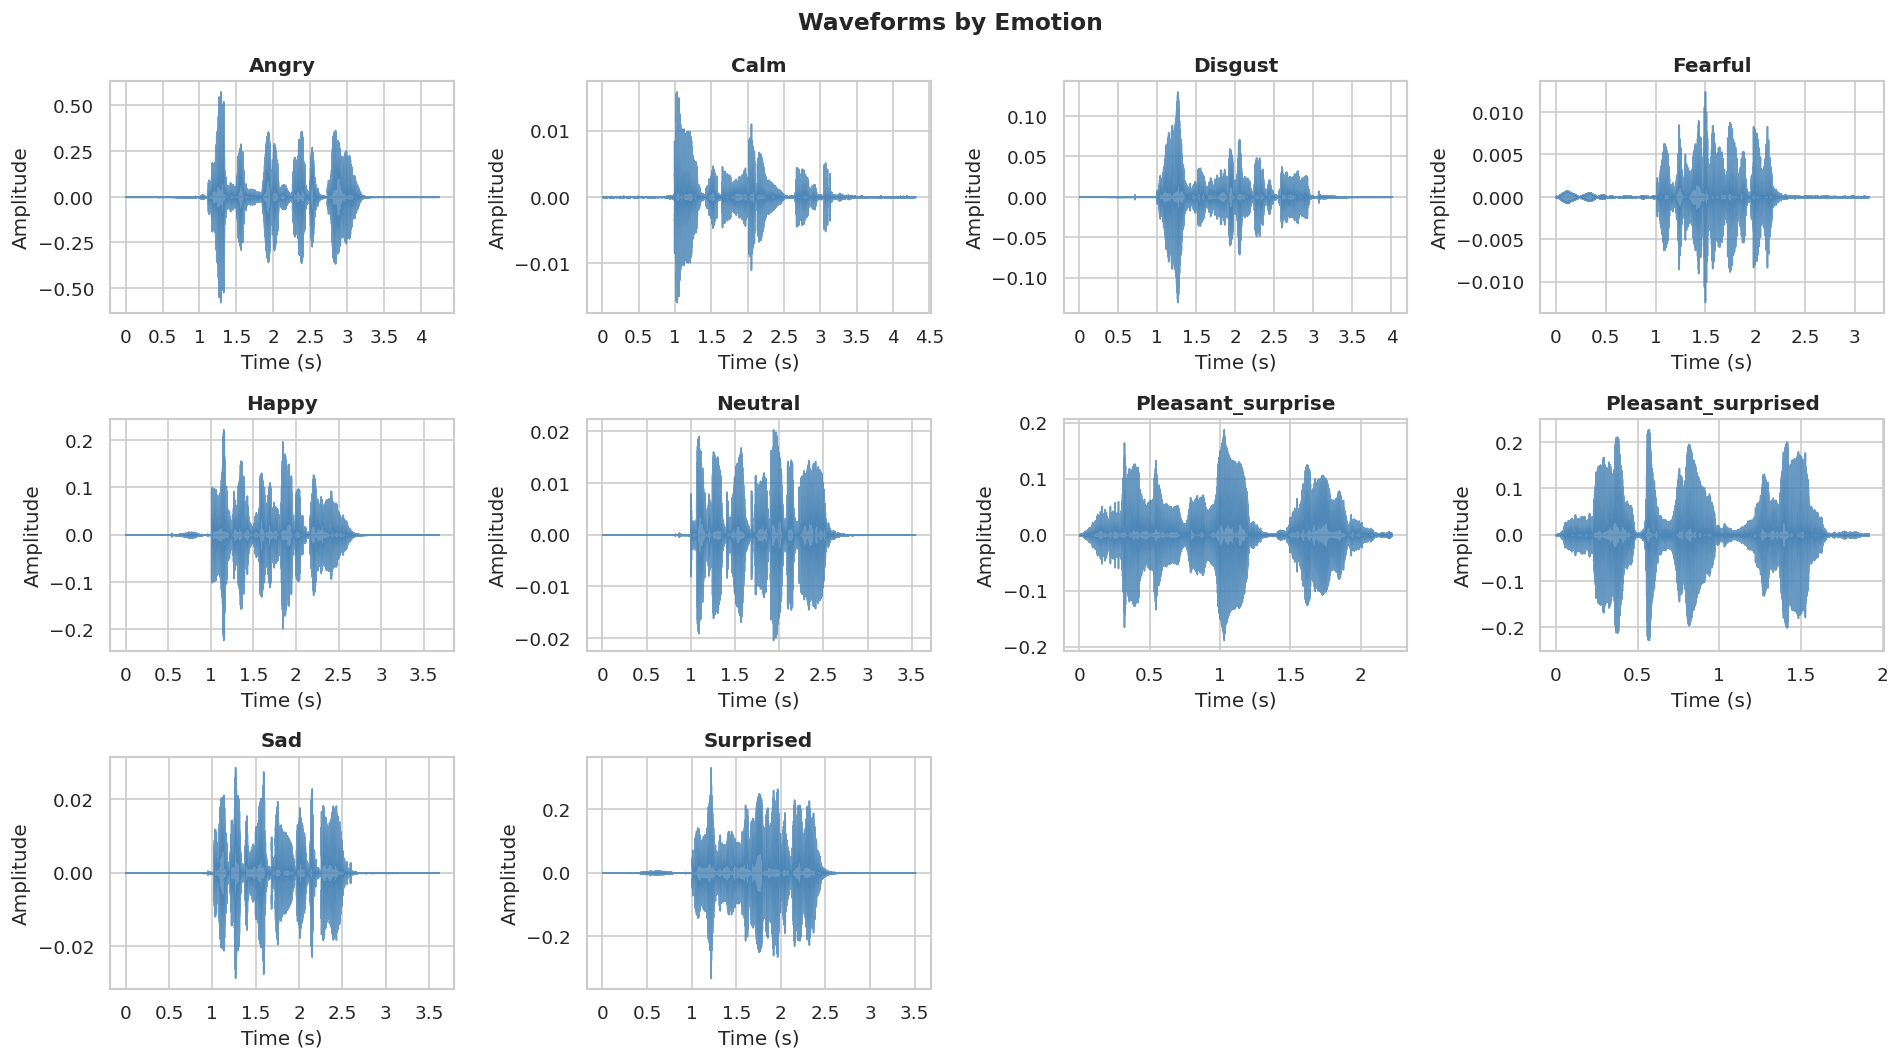

In [11]:
# ── Figure 5: Waveforms ───────────────────────────────────────────────────────
n_emo = len(EMOTIONS_TO_PLOT)
ncols = 4
nrows = (n_emo + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
fig.suptitle('Waveforms by Emotion', fontsize=14, fontweight='bold')

for i, emo in enumerate(EMOTIONS_TO_PLOT):
    y, sr, _ = emotion_examples[emo]
    librosa.display.waveshow(y, sr=sr, ax=axes[i], color='steelblue', alpha=0.8)
    axes[i].set_title(emo.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('eda_waveforms.png', bbox_inches='tight')
plt.show()

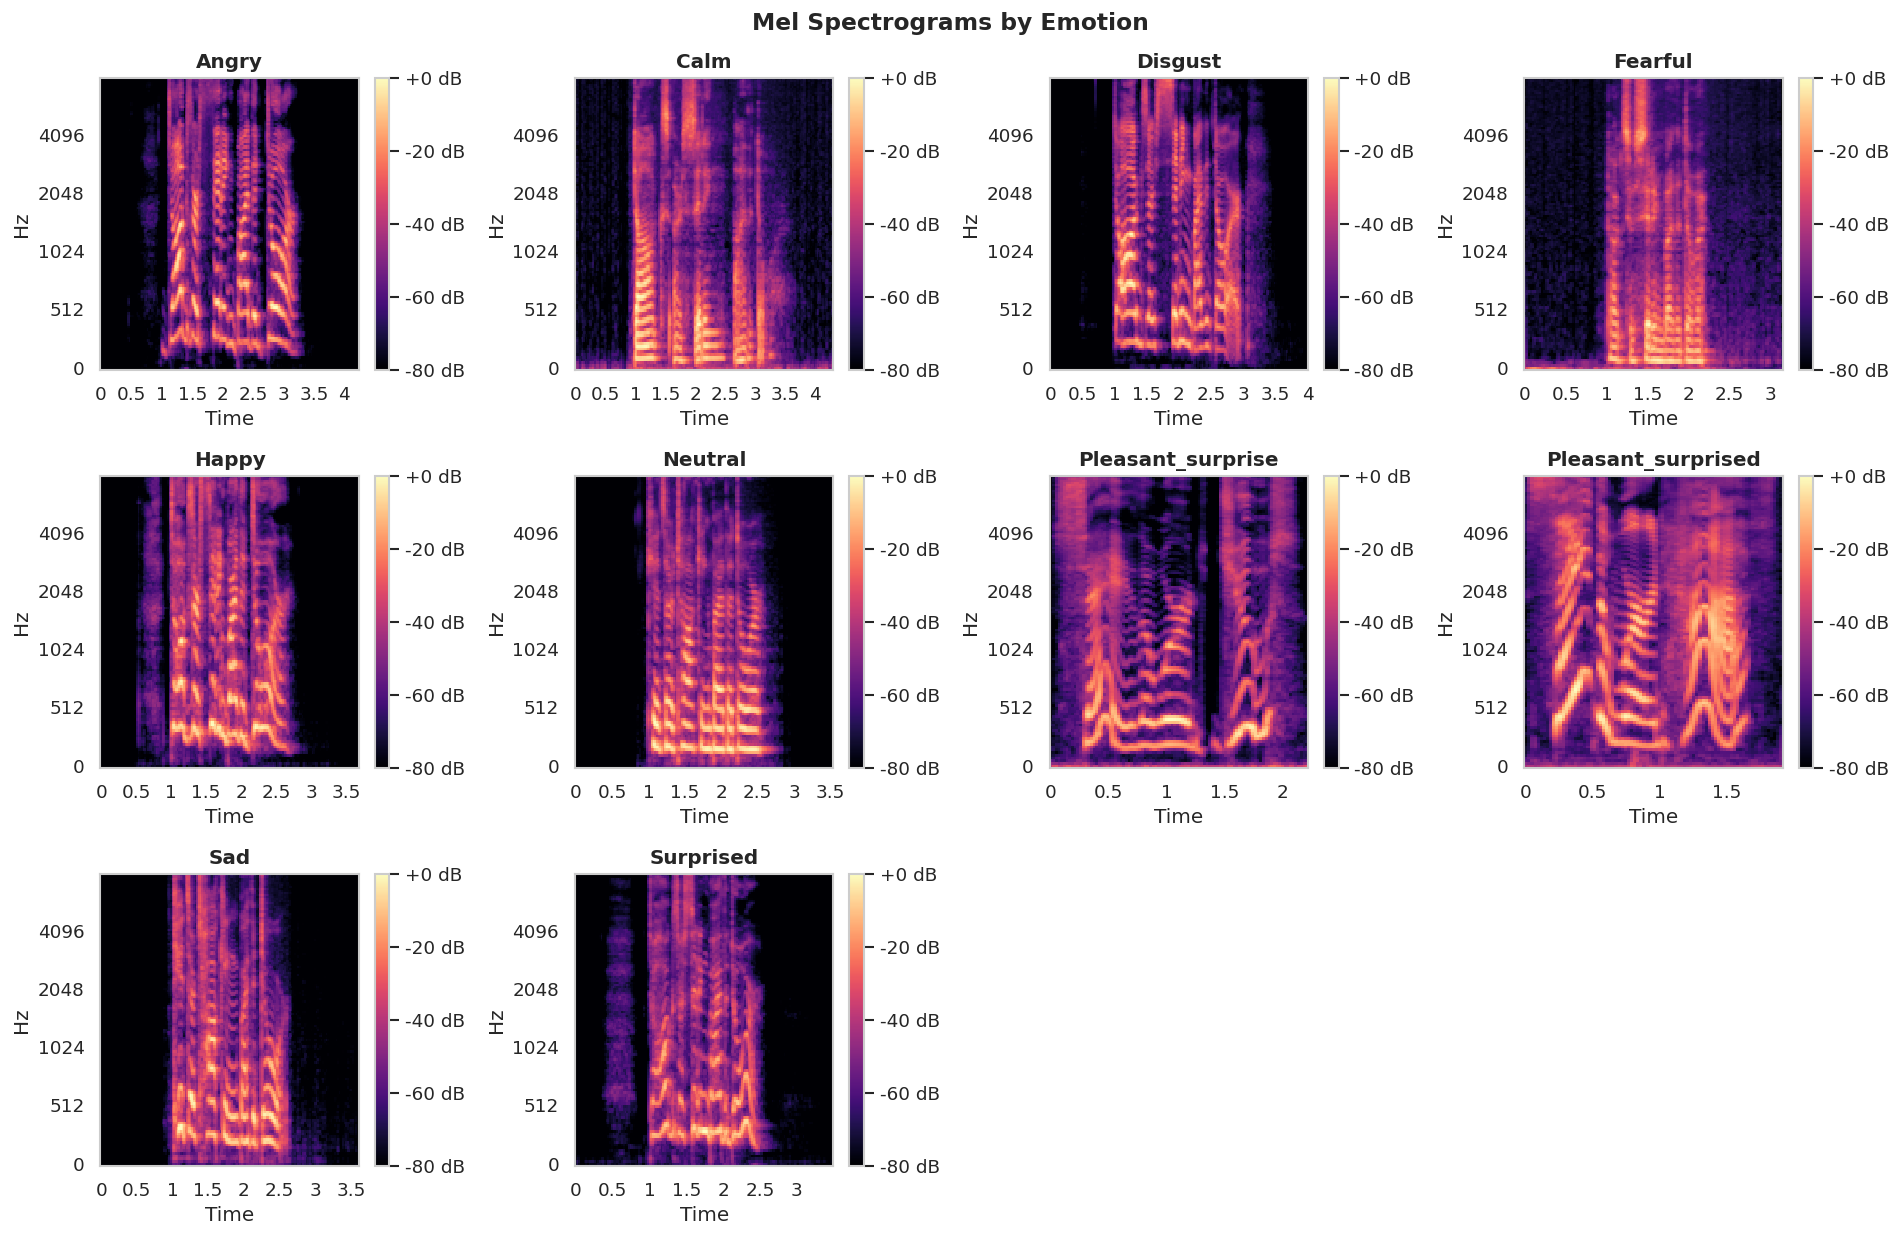

In [12]:
# ── Figure 6: Mel Spectrograms ────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
fig.suptitle('Mel Spectrograms by Emotion', fontsize=14, fontweight='bold')

for i, emo in enumerate(EMOTIONS_TO_PLOT):
    y, sr, _ = emotion_examples[emo]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                                   fmax=8000, ax=axes[i], cmap='magma')
    axes[i].set_title(emo.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Hz')
    plt.colorbar(img, ax=axes[i], format='%+2.0f dB')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('eda_mel_spectrograms.png', bbox_inches='tight')
plt.show()

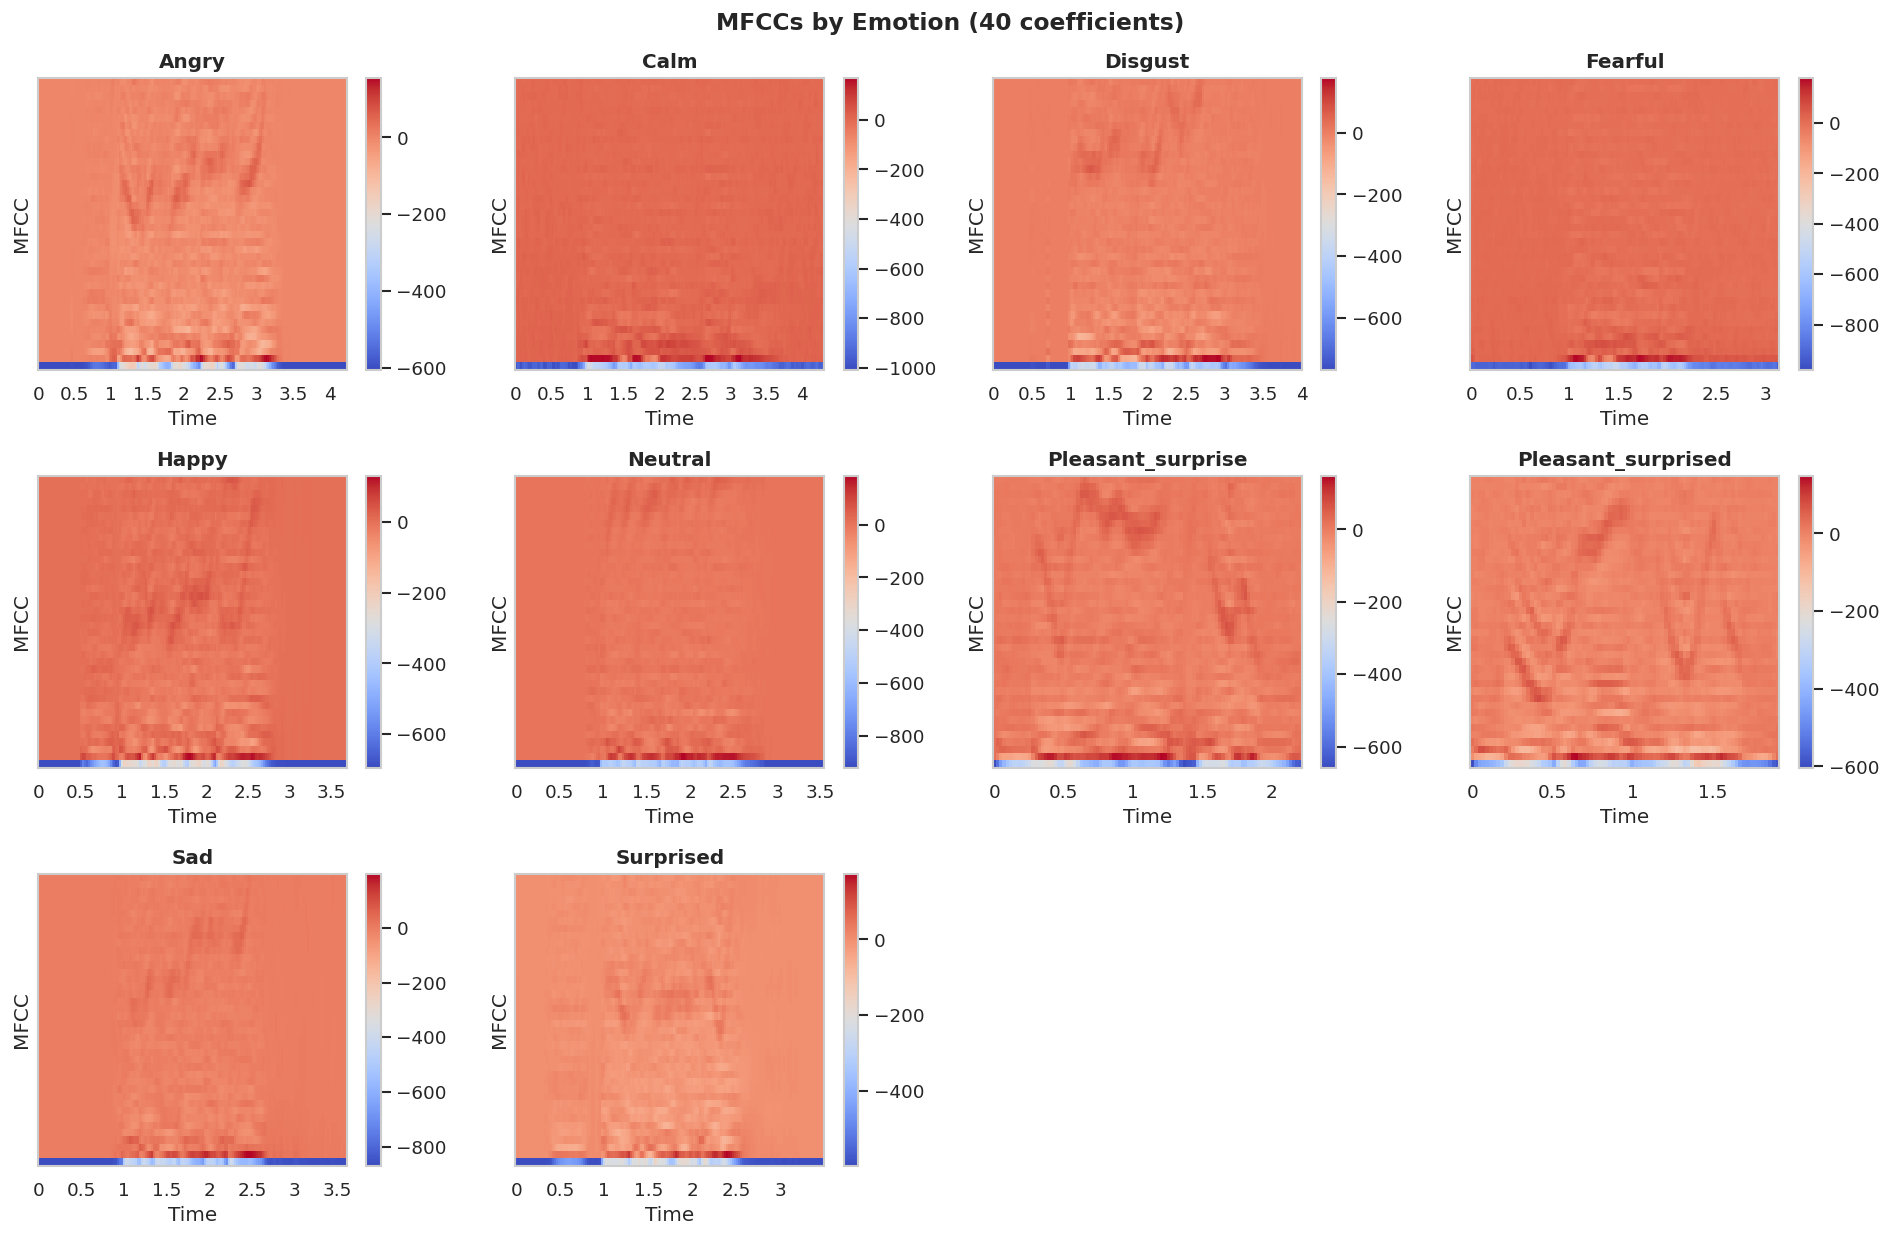

In [13]:
# ── Figure 7: MFCCs ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
fig.suptitle('MFCCs by Emotion (40 coefficients)', fontsize=14, fontweight='bold')

for i, emo in enumerate(EMOTIONS_TO_PLOT):
    y, sr, _ = emotion_examples[emo]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[i], cmap='coolwarm')
    axes[i].set_title(emo.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('MFCC')
    plt.colorbar(img, ax=axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('eda_mfcc.png', bbox_inches='tight')
plt.show()

### 4.5 Aggregate Acoustic Feature Comparison

In [14]:
# ── Extract summary features for all example clips ───────────────────────────
def extract_summary_features(y, sr):
    """Quick scalar features for EDA comparison."""
    mfcc         = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    rms          = librosa.feature.rms(y=y)
    zcr          = librosa.feature.zero_crossing_rate(y)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bw  = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    return {
        'mfcc_mean':       mfcc.mean(),
        'mfcc_std':        mfcc.std(),
        'rms_mean':        rms.mean(),
        'zcr_mean':        zcr.mean(),
        'spectral_centroid_mean': spectral_centroid.mean(),
        'spectral_bw_mean': spectral_bw.mean(),
    }

# Build feature df from the example clips
feat_rows = []
for emo, (y, sr, _) in emotion_examples.items():
    row = extract_summary_features(y, sr)
    row['emotion'] = emo
    feat_rows.append(row)

feat_df = pd.DataFrame(feat_rows).set_index('emotion')
feat_df.round(4)

,mfcc_mean,mfcc_std,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bw_mean
emotion,,,,,,
angry,-39.072899,125.851997,0.0323,0.3071,3221.9079,2576.0091
calm,-49.090900,217.153000,0.0007,0.2608,2973.7799,2792.6194
disgust,-49.631599,163.413696,0.0060,0.3154,3087.7810,2100.1879
fearful,-47.480598,213.830795,0.0008,0.2153,2806.5028,2892.9454
happy,-43.480301,142.366501,0.0145,0.3408,3569.4381,2927.5229
neutral,-54.919201,206.574799,0.0021,0.2414,3376.1234,2588.8620
pleasant_surprise,-29.944500,115.007004,0.0277,0.1368,2674.5924,2395.8982
pleasant_surprised,-28.481100,97.218498,0.0316,0.2116,3339.6769,2234.7495
sad,-53.554401,194.744400,0.0023,0.2860,3165.8827,2502.2754


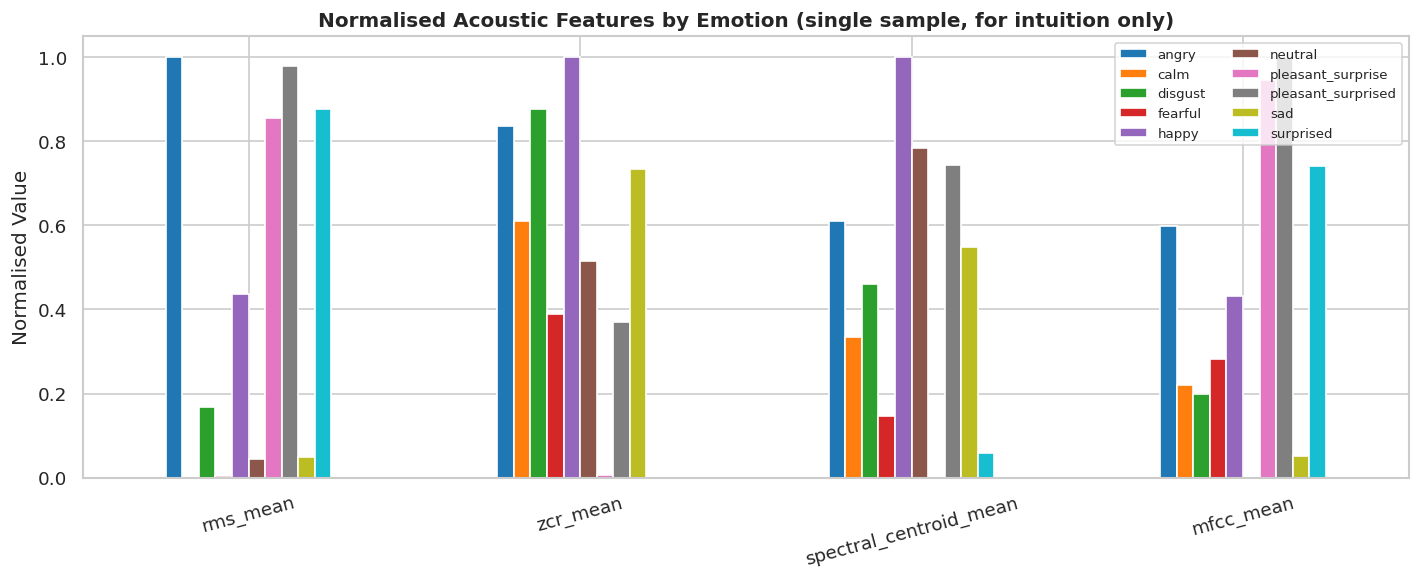

In [16]:
# ── Figure 8: Radar / bar chart of key features per emotion ──────────────────
features_to_plot = ['rms_mean', 'zcr_mean', 'spectral_centroid_mean', 'mfcc_mean']
feat_norm = (feat_df[features_to_plot] - feat_df[features_to_plot].min()) / (feat_df[features_to_plot].max() - feat_df[features_to_plot].min())

fig, ax = plt.subplots(figsize=(12, 5))
feat_norm.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Normalised Acoustic Features by Emotion (single sample, for intuition only)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(features_to_plot, rotation=15)
ax.set_ylabel('Normalised Value')
ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('eda_feature_comparison.png', bbox_inches='tight')
plt.show()

### 4.6 Playback – Listen to One Sample per Emotion

In [17]:
for emo in EMOTIONS_TO_PLOT:
    y, sr, fp = emotion_examples[emo]
    print(f"▶ {emo.upper()} — {Path(fp).name}")
    display(Audio(data=y, rate=sr))

▶ ANGRY — 03-01-05-02-02-01-22.wav


▶ CALM — 03-01-02-02-02-02-05.wav


▶ DISGUST — 03-01-07-01-02-01-24.wav


▶ FEARFUL — 03-01-06-01-02-01-09.wav


▶ HAPPY — 03-01-03-02-02-01-22.wav


▶ NEUTRAL — 03-01-01-01-01-02-18.wav


▶ PLEASANT_SURPRISE — OAF_juice_ps.wav


▶ PLEASANT_SURPRISED — YAF_half_ps.wav


▶ SAD — 03-01-04-01-01-02-14.wav


▶ SURPRISED — 03-01-08-02-02-02-10.wav


## 🔎 5. Assumptions & Hypotheses

*(Criterion 2 from project rubric)*

### 5.1 Data Assumptions

| # | Assumption | Risk if violated |
|---|---|---|
| A1 | Audio clips contain isolated, clearly expressed emotions (acted speech) | Model may not generalise to natural, subtle emotions in the wild |
| A2 | 22 050 Hz resampling preserves all emotionally relevant information | Could lose very high-frequency cues; validate with listening tests |
| A3 | Emotion labels are mutually exclusive (one label per clip) | Real speech often blends emotions; multi-label may be more realistic |
| A4 | Pooling RAVDESS + TESS + SAVEE increases diversity and model robustness | Domain/recording mismatch may add noise; normalise stats per dataset |

### 5.2 Model Hypotheses

| # | Hypothesis | How to test |
|---|---|---|
| H1 | Mel spectrograms are more informative than raw MFCCs alone for emotion classification | Compare CNN trained on mel-spec vs. MFCC feature vector |
| H2 | A CNN–LSTM hybrid (spatial + temporal) outperforms a pure CNN on spectrograms | Ablation study: CNN-only vs. CNN+LSTM |
| H3 | Gender and speaker identity act as confounders; speaker-independent cross-validation reveals true model capability | Compare random vs. speaker-stratified splits |
| H4 | Data augmentation (time-stretch, pitch-shift, noise injection) improves generalisation | Train with/without augmentation; compare validation F1 |
| H5 | Emotions with high acoustic energy (angry, happy) are easier to classify than low-energy emotions (neutral, calm) | Inspect per-class recall in confusion matrix |

---

## 🗓️ 6. Limitations & Ethical Considerations

| Category | Limitation |
|---|---|
| **Acted vs. natural speech** | All three datasets are acted; models may overfit to theatrical expression patterns |
| **Gender imbalance** | TESS (female only) and SAVEE (male only) skew overall gender distribution; model may perform differently across genders |
| **Language & culture** | RAVDESS and TESS: North American English; SAVEE: British English — cultural norms for emotional expression differ |
| **Age** | Datasets lack elderly or child speakers; model won't generalise to those demographics |
| **Privacy** | Audio captures biometric and emotional state data — any deployment must address consent and data minimisation |
| **Label subjectivity** | Emotion perception is subjective; ground-truth labels may not match listener perception |

---

## 🔭 7. Proposed Approach (Draft for Criteria 5 & 6)

*(To be developed in subsequent notebooks)*

### Feature Representations to Explore
1. **Mel spectrogram** (2D image → CNN input)
2. **MFCC + delta + delta-delta** (statistical feature vector → MLP / SVM baseline)
3. **Raw waveform** (1D CNN / WaveNet-style)

### Candidate Architectures

| Model | Input | Rationale |
|---|---|---|
| MLP baseline | MFCC stats | Simple baseline to beat |
| 2D-CNN | Mel spectrogram | Proven strong on SER; captures local spectro-temporal patterns |
| CNN–BiLSTM | Mel spectrogram | Captures long-range temporal dynamics |
| CNN–Transformer | Mel spectrogram | Self-attention for global context; state-of-the-art approach |
| Pre-trained (wav2vec 2.0 / HuBERT) | Raw waveform | Transfer learning; strongest baseline if time allows |

### Regularisation & Overfitting Prevention
- Dropout, batch normalisation
- Early stopping (monitor val loss)
- Data augmentation (SpecAugment, time-stretch, pitch-shift, Gaussian noise)
- Learning rate scheduling (cosine annealing)

### Validation Strategy
- **Speaker-independent split**: hold out 2 RAVDESS actors for test — prevents speaker-identity leakage
- 5-fold cross-validation on training set
- Stratified by emotion to preserve class balance

---

## 💾 8. Save Unified Dataset Manifest

In [18]:
df.to_csv('ser_dataset_manifest.csv', index=False)
print(f"Saved manifest with {len(df):,} rows → ser_dataset_manifest.csv")

# Summary statistics for the report
summary = df.groupby(['dataset', 'emotion', 'gender']).size().reset_index(name='count')
summary.to_csv('ser_class_counts.csv', index=False)
print("Saved class counts → ser_class_counts.csv")

Saved manifest with 8,960 rows → ser_dataset_manifest.csv
Saved class counts → ser_class_counts.csv


---
## ✅ EDA Checklist

| Task | Status |
|---|---|
| Parse & unify all three datasets | ✅ |
| Class distribution analysis | ✅ |
| Speaker / gender breakdown | ✅ |
| Audio duration analysis | ✅ |
| Waveform visualisation per emotion | ✅ |
| Mel spectrogram visualisation | ✅ |
| MFCC visualisation | ✅ |
| Aggregate acoustic feature comparison | ✅ |
| Assumptions & hypotheses drafted | ✅ |
| Limitations documented | ✅ |
| Proposed model architecture draft | ✅ |
| Dataset manifest saved | ✅ |

**Next steps:** Feature engineering notebook (Criterion 4) — extract full feature matrix (MFCCs, chroma, spectral contrast, tonnetz) and build train/val/test splits.